# Дипломная работа: Детекция переутомления спортсмена
## Гибридная модель CNN + LSTM на данных носимых датчиков

**Цель:** Разработка системы автоматического определения переутомления спортсмена

**Датасеты (3 источника):**
- **Zenodo Running IMU** (19 субъектов) — бег 400м до/после Beep Test, IMU 256 Hz
- **4TU Marotta** (19 субъектов) — бег 4км + протокол утомления до RPE>16, IMU 240 Hz
- **PhysioNet Wearable Device** (до 31 субъекта) — Empatica E4: ACC(32Hz), BVP(64Hz), EDA(4Hz), TEMP(4Hz), HR(1Hz). Протоколы AEROBIC (cycling) и ANAEROBIC (Wingate)

**Данные (dual-branch):**
- `X_imu`:   (N, 100, 6) — ax, ay, az, gx, gy, gz
- `X_physio`: (N, 100, 4) — bvp, eda, temp, hr
- `has_physio`: маска наличия физиологических каналов

**Модель:** CNN + LSTM (двухветочная, ~474K параметров)
- IMU-ветка: 3×Conv1D → 256-dim
- Physio-ветка: 3×Conv1D → 128-dim
- LSTM: BiLSTM(128) для временной динамики
- Classifier: 384 → 128 → 1

In [1]:
# Imports
import os
import sys
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import (
    f1_score, roc_auc_score, balanced_accuracy_score,
    confusion_matrix, classification_report, precision_recall_curve, auc
)

# Add path to afc module
sys.path.insert(0, str(Path.cwd().parent))
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

SEED = 5573210

def set_seed(seed=7321):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, 'cudnn'):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Random seed fixed: {SEED}")


PyTorch version: 2.10.0+cu130
CUDA available: True
Using device: cuda
Random seed fixed: 5573210


## 2. Загрузка и исследование данных

Загружаем композиционный датасет из `data/processed/composite_full.npz`:
- `X_imu`:   (N, 100, 6) — акселерометр + гироскоп (ax, ay, az, gx, gy, gz)
- `X_physio`: (N, 100, 4) — физиологические каналы (bvp, eda, temp, hr)
- `y`: метки (0=норма, 1=усталость)
- `pids`: ID субъектов ("zenodo_X", "4tu_X", "physionet_X_protocol")
- `domains`: источник ("zenodo", "4tu", "physionet")
- `has_physio`: маска наличия физиологических данных (True для PhysioNet)

### 2.1 Сборка комплексного датасета (AFC v4: + WSD4FEDSRM)

Добавляем 4-й источник — **WSD4FEDSRM** (Zenodo 8415066): вращения плеча до отказа, 34 субъекта, IMU (Sternum) + PPG.

Стратегия:
- IMU: `acc_sternum.csv` (3 оси) + `gyr_sternum.csv` (3 оси) @ 100 Hz
- PPG: `ppg.csv` @ 200 Hz → physio-канал `bvp`
- Разметка по Borg RPE: ≤11 → норма (0), ≥14 → усталость (1), 12–13 → исключаются
- Нарезка по 10-секундным интервалам (соответствуют оценкам RPE), ресемплинг до 100 точек

In [2]:
# ── Проверка composite_full.npz (все 4 домена должны быть из build_dataset.py) ──

PROJECT_ROOT_TMP = Path(os.getcwd()).resolve()
for _ in range(5):
    if (PROJECT_ROOT_TMP / 'config.yaml').exists():
        break
    PROJECT_ROOT_TMP = PROJECT_ROOT_TMP.parent

DATA_FILE_TMP = PROJECT_ROOT_TMP / 'data' / 'processed' / 'composite_full.npz'

if DATA_FILE_TMP.exists():
    _check = np.load(DATA_FILE_TMP, allow_pickle=True)
    _domains = np.unique(_check['domains'])
    _expected = {'zenodo', '4tu', 'physionet', 'wsd4fedsrm'}
    _missing = _expected - set(_domains)
    if _missing:
        print(f"⚠️ В composite_full.npz отсутствуют домены: {_missing}")
        print("   Запустите: python scripts/build_dataset.py")
    else:
        print(f"✅ composite_full.npz содержит все 4 домена: {list(_domains)}")
        print(f"   Окон: {len(_check['y'])}, субъектов: {len(np.unique(_check['pids']))}")
    del _check
else:
    print(f"❌ Файл не найден: {DATA_FILE_TMP}")
    print("   Запустите: python scripts/build_dataset.py")

✅ composite_full.npz содержит все 4 домена: [np.str_('4tu'), np.str_('physionet'), np.str_('wsd4fedsrm'), np.str_('zenodo')]
   Окон: 46573, субъектов: 91


In [10]:
# Robust project root detection
def find_project_root(marker='config.yaml', start=None, max_levels=5):
    """Find project root by marker file, moving up the tree."""
    current = Path(start or os.getcwd()).resolve()
    for _ in range(max_levels):
        if (current / marker).exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise FileNotFoundError(
        f"Marker '{marker}' not found. CWD={os.getcwd()}. "
        f"Run notebook from project directory."
    )

PROJECT_ROOT = find_project_root('config.yaml')
DATA_FILE = PROJECT_ROOT / 'data' / 'processed' / 'composite_full.npz'
RESULTS_DIR = (PROJECT_ROOT / 'results_review').resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data file:    {DATA_FILE} (exists={DATA_FILE.exists()})")
print(f"Results dir:  {RESULTS_DIR}")


Project root: D:\Github\afc_lab
Data file:    D:\Github\afc_lab\data\processed\composite_full.npz (exists=True)
Results dir:  D:\Github\afc_lab\results_review


In [4]:
# Загрузка композиционного датасета (dual-branch)
print(f"Загрузка данных из {DATA_FILE}...")

data = np.load(DATA_FILE, allow_pickle=True)

X_imu_all = data['X_imu'].astype(np.float32)       # (N, 100, 6)
X_physio_all = data['X_physio'].astype(np.float32)   # (N, 100, 4)
y_all = data['y'].astype(np.int64)                   # (N,)
subjects = data['pids']                               # (N,)
domains = data['domains']                             # (N,)
has_physio = data['has_physio'].astype(bool)           # (N,)
imu_channels = data['imu_channels']                   # ['ax','ay','az','gx','gy','gz']
physio_channels = data['physio_channels']             # ['bvp','eda','temp','hr']

print(f"\n✅ Данные загружены:")
print(f"   X_imu shape:    {X_imu_all.shape}")
print(f"   X_physio shape: {X_physio_all.shape}")
print(f"   y shape:        {y_all.shape}")
print(f"   IMU каналы:     {list(imu_channels)}")
print(f"   Physio каналы:  {list(physio_channels)}")
print(f"   Субъектов:      {len(np.unique(subjects))}")
print(f"   Доменов:        {list(np.unique(domains))}")
print(f"   has_physio:     {has_physio.sum()}/{len(has_physio)} ({has_physio.mean()*100:.1f}%)")


Загрузка данных из D:\Github\afc_lab\data\processed\composite_full.npz...

✅ Данные загружены:
   X_imu shape:    (46573, 100, 6)
   X_physio shape: (46573, 100, 4)
   y shape:        (46573,)
   IMU каналы:     [np.str_('ax'), np.str_('ay'), np.str_('az'), np.str_('gx'), np.str_('gy'), np.str_('gz')]
   Physio каналы:  [np.str_('bvp'), np.str_('eda'), np.str_('temp'), np.str_('hr')]
   Субъектов:      91
   Доменов:        [np.str_('4tu'), np.str_('physionet'), np.str_('wsd4fedsrm'), np.str_('zenodo')]
   has_physio:     23034/46573 (49.5%)


In [5]:
df_view = pd.DataFrame(X_imu_all.reshape(X_imu_all.shape[0], -1), columns=[f"{ch}_{t}" for ch in imu_channels for t in range(X_imu_all.shape[1])])
df_view.head(10)

,ax_0,ax_1,ax_2,ax_3,ax_4,ax_5,ax_6,ax_7,ax_8,ax_9,...,gz_90,gz_91,gz_92,gz_93,gz_94,gz_95,gz_96,gz_97,gz_98,gz_99
0,0.114111,-0.698034,-0.416269,0.134061,0.233338,-0.801674,0.301462,-0.642978,0.672917,-0.107133,...,0.750359,-0.122401,-1.062782,-1.560246,0.257955,-0.687226,-0.114013,0.083114,-0.293576,-1.077626
1,0.631300,-0.713949,0.385606,-0.136960,-0.852827,-1.395672,0.715246,-0.715108,0.396508,-0.026430,...,0.552606,0.668905,-1.327065,-0.514125,0.170679,-0.930780,0.479457,0.072117,-1.002151,-1.072949
2,-0.001610,-1.020297,0.598151,0.166494,-0.850925,-1.110366,0.438024,-0.810365,0.734773,-0.255524,...,0.819005,0.405341,-1.286426,-0.200661,0.005663,-0.965260,0.722366,0.340493,-1.040195,-0.745549
3,0.285430,-0.855187,0.827258,0.220782,-1.011662,-0.937312,0.548628,-0.771001,0.818656,-0.030498,...,0.091018,0.107243,-0.406758,-1.251885,0.233711,-0.853198,0.370424,0.340493,-0.721574,-1.016823
4,0.228863,-0.847230,-0.007740,0.695452,-0.576055,-0.977067,0.346781,-0.843539,-0.103000,0.977478,...,1.060296,0.445132,-1.607305,-0.578990,-0.029409,-0.934758,0.473936,0.488045,-0.926062,-0.888202
5,0.458365,-0.926138,0.977696,-0.069866,-1.211394,-1.187539,0.774343,-0.848335,1.039733,-0.323192,...,-0.127299,1.055233,-0.519872,-0.779871,0.350079,-0.919507,0.272433,0.667612,-0.973618,-0.825060
6,0.419576,-0.784236,-0.416269,1.175689,-0.992640,-0.457904,0.305331,-0.819849,-0.797849,1.187739,...,0.310980,0.858582,-0.307295,-1.425672,0.322603,-0.808771,-0.111253,1.111657,-0.700650,-0.906910
7,0.246641,-0.886352,-0.285429,1.185433,-0.433389,-1.192216,0.337182,-0.878375,-0.471739,1.220317,...,-0.085866,1.237105,-0.533803,-1.295680,0.333917,-0.941389,-0.272732,1.296792,-0.479042,-1.238987
8,0.343614,-0.941389,-0.465402,1.455480,-0.616952,-0.963036,0.307061,-0.919882,-0.729022,1.367981,...,0.278065,1.123299,-0.184285,-1.028516,0.325836,-0.939400,-0.162319,1.441560,-0.422926,-1.035532
9,0.304825,-0.973217,-0.024302,1.294008,-0.361104,-0.946666,0.450562,-1.003157,-0.456879,1.296764,...,-0.161120,1.192252,-0.554429,-1.058067,0.330684,-0.953325,-0.104352,1.164553,-0.566544,-0.906910


In [11]:
# Анализ распределения данных
df_meta = pd.DataFrame({
    'sid': subjects,
    'domain': domains,
    'y': y_all,
    'has_physio': has_physio,
})

print("=" * 60)
print("СТАТИСТИКА ДАТАСЕТА")
print("=" * 60)

# Распределение по доменам
print("\n📊 Распределение по источникам данных:")
print(df_meta['domain'].value_counts())

# Распределение по классам
print("\n📊 Распределение по классам (0=норма, 1=усталость):")
print(df_meta['y'].value_counts())
print(f"\nБаланс классов: {df_meta['y'].mean():.2%} положительных")

# Количество субъектов
print(f"\n👥 Уникальных субъектов: {df_meta['sid'].nunique()}")
print("По доменам:")
for domain in sorted(df_meta['domain'].unique()):
    mask = df_meta['domain'] == domain
    n_subj = df_meta[mask]['sid'].nunique()
    n_physio = df_meta[mask]['has_physio'].sum()
    print(f"  - {domain}: {n_subj} субъектов, {mask.sum()} окон, has_physio={n_physio}")


СТАТИСТИКА ДАТАСЕТА

📊 Распределение по источникам данных:
domain
physionet     23034
4tu           16410
zenodo         6006
wsd4fedsrm     1123
Name: count, dtype: int64

📊 Распределение по классам (0=норма, 1=усталость):
y
0    28953
1    17620
Name: count, dtype: int64

Баланс классов: 37.83% положительных

👥 Уникальных субъектов: 91
По доменам:
  - 4tu: 7 субъектов, 16410 окон, has_physio=0
  - physionet: 31 субъектов, 23034 окон, has_physio=23034
  - wsd4fedsrm: 34 субъектов, 1123 окон, has_physio=0
  - zenodo: 19 субъектов, 6006 окон, has_physio=0


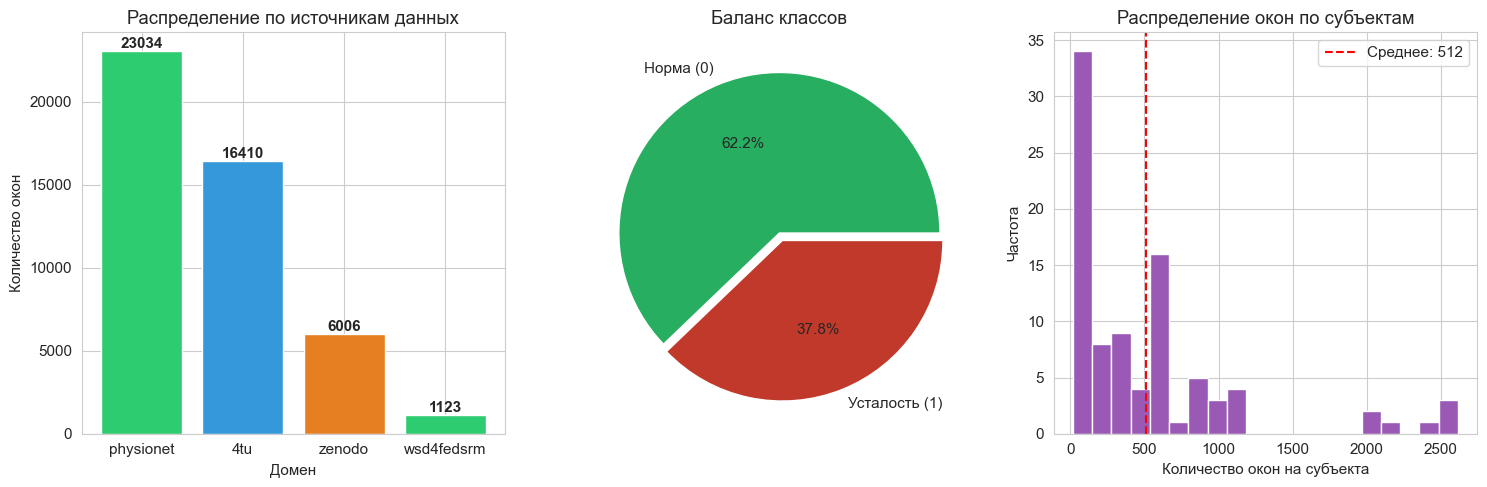

In [12]:
# Визуализация распределений
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Распределение по доменам
domain_counts = df_meta['domain'].value_counts()
colors_domain = ['#2ecc71', '#3498db', '#e67e22'][:len(domain_counts)]
axes[0].bar(domain_counts.index, domain_counts.values, color=colors_domain)
axes[0].set_title('Распределение по источникам данных')
axes[0].set_xlabel('Домен')
axes[0].set_ylabel('Количество окон')
for i, v in enumerate(domain_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# 2. Распределение по классам
class_counts = df_meta['y'].value_counts().sort_index()
colors_class = ['#27ae60', '#c0392b']
axes[1].pie(class_counts.values, labels=['Норма (0)', 'Усталость (1)'],
            autopct='%1.1f%%', colors=colors_class, explode=[0, 0.05])
axes[1].set_title('Баланс классов')

# 3. Распределение окон по субъектам
subj_counts = df_meta.groupby('sid').size()
axes[2].hist(subj_counts, bins=20, color='#9b59b6', edgecolor='white')
axes[2].set_title('Распределение окон по субъектам')
axes[2].set_xlabel('Количество окон на субъекта')
axes[2].set_ylabel('Частота')
axes[2].axvline(subj_counts.mean(), color='red', linestyle='--', label=f'Среднее: {subj_counts.mean():.0f}')
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


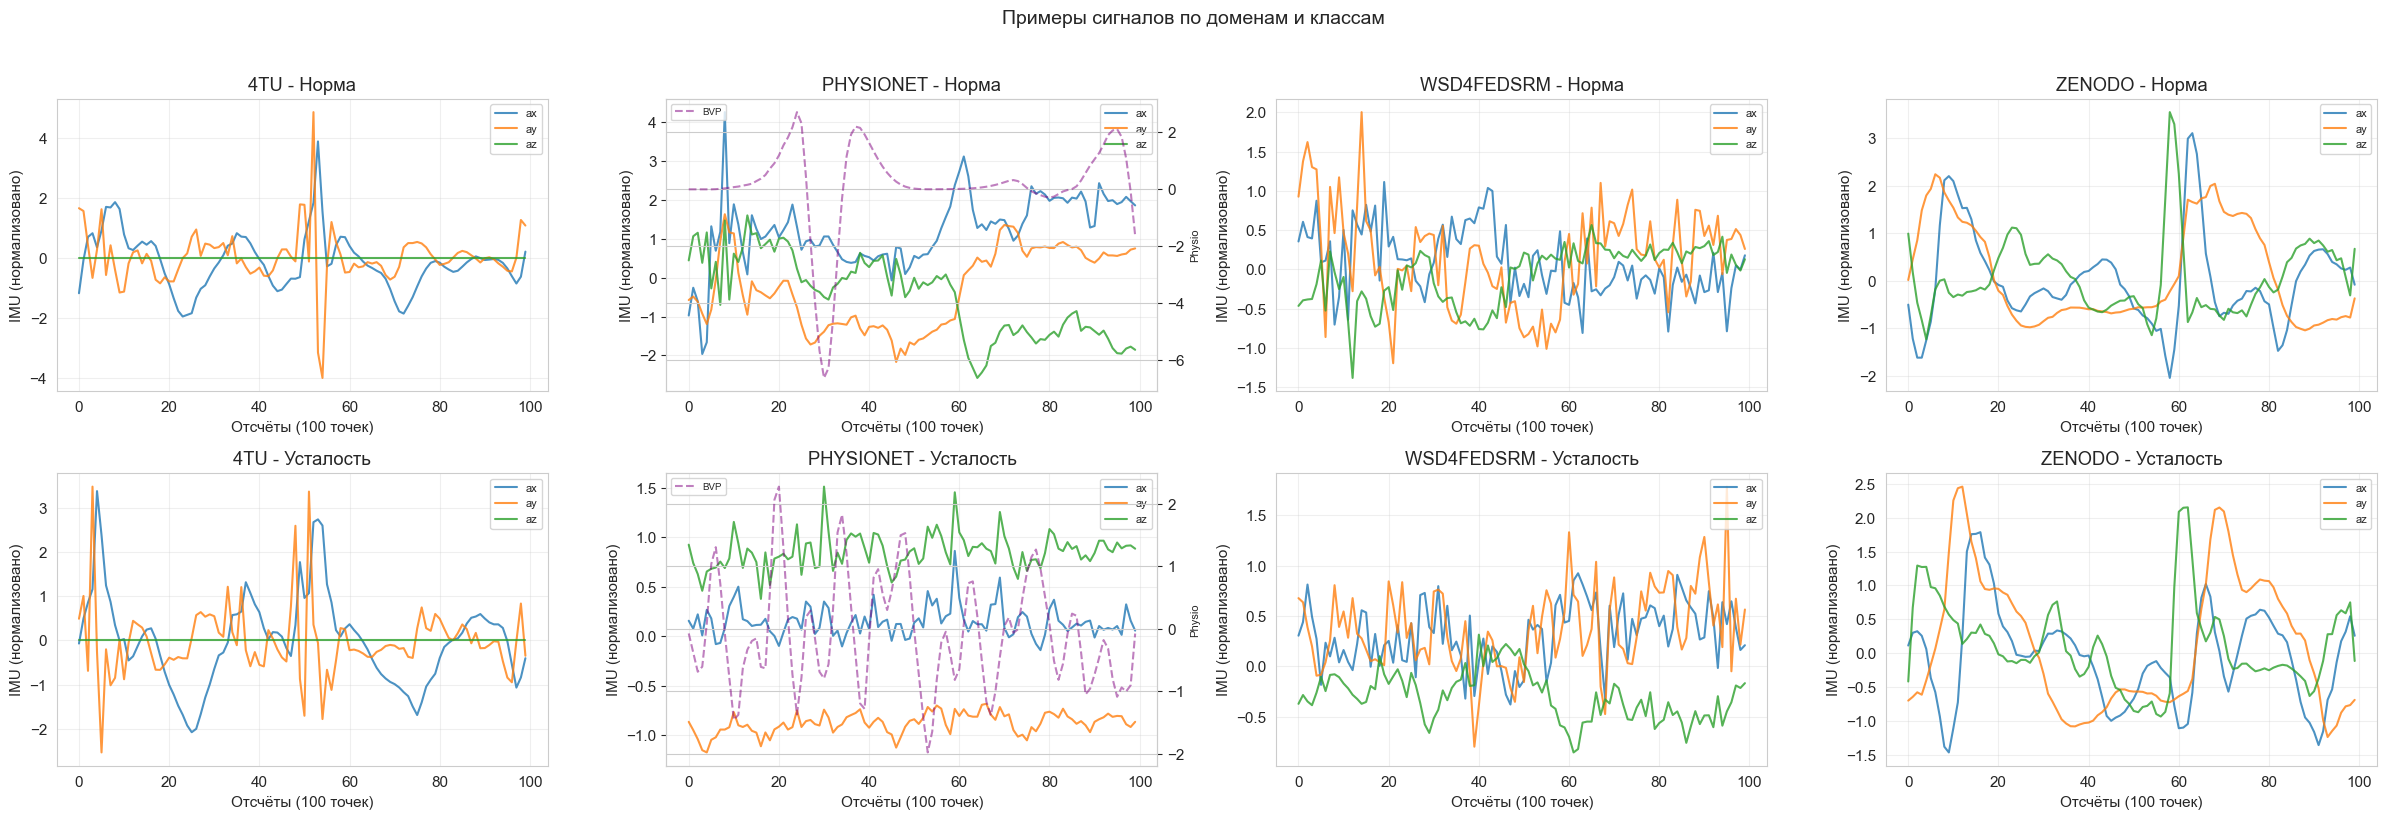

In [13]:
# Визуализация примеров сигналов по доменам
unique_domains = sorted(np.unique(domains))
n_domains = len(unique_domains)
fig, axes = plt.subplots(2, n_domains, figsize=(6 * n_domains, 8))

for col, domain in enumerate(unique_domains):
    domain_mask = domains == domain

    for row, label in enumerate([0, 1]):
        label_mask = y_all == label
        combined_mask = domain_mask & label_mask
        indices = np.where(combined_mask)[0]

        ax = axes[row, col] if n_domains > 1 else axes[row]

        if len(indices) > 0:
            idx = indices[0]
            X = X_imu_all[idx]  # (100, 6)
            time_axis = np.arange(X.shape[0])

            for ch in range(3):  # ax, ay, az
                ax.plot(time_axis, X[:, ch], label=f'a{["x","y","z"][ch]}', alpha=0.8)

            # Если есть physio-данные — отобразим на вторичной оси
            if has_physio[idx]:
                ax2 = ax.twinx()
                Xp = X_physio_all[idx]
                ax2.plot(time_axis, Xp[:, 0], '--', color='purple', alpha=0.5, label='BVP')
                ax2.set_ylabel('Physio', fontsize=8)
                ax2.legend(loc='upper left', fontsize=7)

            status = 'Усталость' if label == 1 else 'Норма'
            ax.set_title(f'{domain.upper()} - {status}')
            ax.set_xlabel('Отсчёты (100 точек)')
            ax.set_ylabel('IMU (нормализовано)')
            ax.legend(loc='upper right', fontsize=8)
            ax.grid(True, alpha=0.3)

plt.suptitle('Примеры сигналов по доменам и классам', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'signal_examples.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Подготовка данных для обучения

### 3.1 Формирование фолдов

Используем два подхода к валидации:
1. **LOSO (Leave-One-Subject-Out)** — для оценки обобщающей способности
2. **Train/Val/Test Split** — по субъектам, стратифицировано по доменам

### 3.2 Данные (dual-branch)

Данные уже нормализованы (Z-score по субъектам) при сборке датасета:
- **IMU:** 100 точек × 6 каналов (ax, ay, az, gx, gy, gz)
- **Physio:** 100 точек × 4 канала (bvp, eda, temp, hr) — только для PhysioNet

In [14]:
# Конфигурация данных
IMU_CHANNELS = 6      # ax, ay, az, gx, gy, gz
PHYSIO_CHANNELS = 4   # bvp, eda, temp, hr
TARGET_SAMPLES = 100  # 100 точек на окно

print(f"✅ Данные подготовлены:")
print(f"   X_imu shape:    {X_imu_all.shape}")
print(f"   X_physio shape: {X_physio_all.shape}")
print(f"   y shape:        {y_all.shape}")
print(f"   Субъектов:      {len(np.unique(subjects))}")
print(f"   Доменов:        {len(np.unique(domains))}")
print(f"   has_physio:     {has_physio.sum()}/{len(has_physio)}")
print(f"   NaN (IMU):      {np.isnan(X_imu_all).sum()}")
print(f"   NaN (Physio):   {np.isnan(X_physio_all).sum()}")


✅ Данные подготовлены:
   X_imu shape:    (46573, 100, 6)
   X_physio shape: (46573, 100, 4)
   y shape:        (46573,)
   Субъектов:      91
   Доменов:        4
   has_physio:     23034/46573
   NaN (IMU):      0
   NaN (Physio):   0


In [15]:
# Create LOSO folds
def create_loso_folds(subjects):
    """Create Leave-One-Subject-Out folds."""
    unique_subjects = np.unique(subjects)
    folds = []

    for test_subject in unique_subjects:
        train_mask = subjects != test_subject
        test_mask = subjects == test_subject
        folds.append({
            'train_idx': np.where(train_mask)[0],
            'test_idx': np.where(test_mask)[0],
            'test_subject': test_subject
        })

    return folds


def create_subject_split(subjects, domains, y=None, test_size=0.2, val_size=0.2, random_state=7321):
    """Subject-level split (not window-level), stratified by domain."""
    if test_size + val_size >= 1.0:
        raise ValueError("test_size + val_size must be < 1.0")

    subj_df = pd.DataFrame({'sid': subjects, 'domain': domains}).drop_duplicates(subset='sid')

    # Ensure each subject belongs to a single domain
    dom_counts = subj_df.groupby('sid')['domain'].nunique()
    if (dom_counts > 1).any():
        bad_subjects = dom_counts[dom_counts > 1].index.tolist()
        raise ValueError(f"Subjects mapped to multiple domains: {bad_subjects}")

    sid_values = subj_df['sid'].to_numpy()
    sid_domains = subj_df['domain'].to_numpy()

    strat_test = sid_domains if len(np.unique(sid_domains)) > 1 else None
    sid_train_val, sid_test = train_test_split(
        sid_values,
        test_size=test_size,
        random_state=random_state,
        stratify=strat_test,
    )

    val_rel = val_size / (1.0 - test_size)
    train_val_df = subj_df[subj_df['sid'].isin(sid_train_val)]
    train_val_domains = train_val_df.set_index('sid').loc[sid_train_val, 'domain'].to_numpy()
    strat_val = train_val_domains if len(np.unique(train_val_domains)) > 1 else None

    sid_train, sid_val = train_test_split(
        sid_train_val,
        test_size=val_rel,
        random_state=random_state,
        stratify=strat_val,
    )

    train_idx = np.where(np.isin(subjects, sid_train))[0]
    val_idx = np.where(np.isin(subjects, sid_val))[0]
    test_idx = np.where(np.isin(subjects, sid_test))[0]

    if y is not None:
        for name, idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
            if len(np.unique(y[idx])) < 2:
                raise ValueError(f"Split {name} has one class only. Adjust split parameters.")

    split_info = {
        'train_subjects': sorted(sid_train.tolist()),
        'val_subjects': sorted(sid_val.tolist()),
        'test_subjects': sorted(sid_test.tolist()),
    }
    return train_idx, val_idx, test_idx, split_info


def print_split_summary(name, idx, subjects, domains, y, total_n):
    split_subjects = np.unique(subjects[idx])
    dom_values, dom_counts = np.unique(domains[idx], return_counts=True)
    class_counts = np.bincount(y[idx].astype(int), minlength=2)

    print(f"{name}: {len(idx)} windows ({len(idx)/total_n*100:.1f}%) | subjects: {len(split_subjects)}")
    print(f"  Domains: {dict(zip(dom_values.tolist(), dom_counts.tolist()))}")
    print(f"  Classes: 0 -> {class_counts[0]}, 1 -> {class_counts[1]}, pos_ratio={y[idx].mean():.1%}")


# Build split
train_idx, val_idx, test_idx, split_info = create_subject_split(
    subjects,
    domains,
    y=y_all,
    test_size=0.2,
    val_size=0.2,
    random_state=SEED,
)

print_split_summary('Train', train_idx, subjects, domains, y_all, len(y_all))
print_split_summary('Val', val_idx, subjects, domains, y_all, len(y_all))
print_split_summary('Test', test_idx, subjects, domains, y_all, len(y_all))

print("Subjects by split:")
print(f"  Train ({len(split_info['train_subjects'])}): {', '.join(split_info['train_subjects'])}")
print(f"  Val   ({len(split_info['val_subjects'])}): {', '.join(split_info['val_subjects'])}")
print(f"  Test  ({len(split_info['test_subjects'])}): {', '.join(split_info['test_subjects'])}")


Train: 29254 windows (62.8%) | subjects: 54
  Domains: {'4tu': 11670, 'physionet': 13369, 'wsd4fedsrm': 619, 'zenodo': 3596}
  Classes: 0 -> 18550, 1 -> 10704, pos_ratio=36.6%
Val: 9054 windows (19.4%) | subjects: 18
  Domains: {'4tu': 2614, 'physionet': 4895, 'wsd4fedsrm': 253, 'zenodo': 1292}
  Classes: 0 -> 5620, 1 -> 3434, pos_ratio=37.9%
Test: 8265 windows (17.7%) | subjects: 19
  Domains: {'4tu': 2126, 'physionet': 4770, 'wsd4fedsrm': 251, 'zenodo': 1118}
  Classes: 0 -> 4783, 1 -> 3482, pos_ratio=42.1%
Subjects by split:
  Train (54): 4tu_1, 4tu_2, 4tu_3, 4tu_5, 4tu_8, physionet_S01, physionet_S02, physionet_S05, physionet_S07, physionet_S09, physionet_S12, physionet_S15, physionet_S16, physionet_S17, physionet_S18, physionet_f02, physionet_f03, physionet_f06, physionet_f07, physionet_f08, physionet_f10, physionet_f12, physionet_f13, wsd_002, wsd_004, wsd_007, wsd_009, wsd_010, wsd_011, wsd_012, wsd_013, wsd_014, wsd_018, wsd_019, wsd_020, wsd_021, wsd_023, wsd_024, wsd_028, wsd

## 4. Архитектура модели CNN + LSTM (двухветочная)

### Структура сети FatigueCNN_LSTM:

```
IMU Input (batch, 100, 6) ─────────────────────  Physio Input (batch, 100, 4)
        ↓                                                  ↓
  Conv1D(6→64, k=7)→BN→ReLU→Pool→Drop            Conv1D(4→32, k=7)→BN→ReLU→Pool→Drop
  Conv1D(64→128, k=5)→BN→ReLU→Pool→Drop           Conv1D(32→64, k=5)→BN→ReLU→Pool→Drop
  Conv1D(128→256, k=3)→BN→ReLU→GAP                Conv1D(64→128, k=3)→BN→ReLU→GAP
        ↓ (256-dim)                                        ↓ (128-dim)
        └────────────────── Concat ────────────────────────┘
                              ↓ (384-dim)
                      BiLSTM(hidden=128)
                              ↓ (256-dim)
                  Linear(256→128)→ReLU→Drop
                  Linear(128→1)→Sigmoid
                              ↓
                      Output: P(fatigue)
```

**Параметров:** ~474K (IMU-ветка ~228K + Physio-ветка ~90K + LSTM ~132K + Classifier ~24K)

In [16]:
# ── Аугментация данных (on-the-fly) ──

from scipy.interpolate import CubicSpline
from scipy.signal import resample as sp_resample


def add_gaussian_noise(x, sigma=0.05):
    """x: (T, C) -> (T, C)"""
    return x + np.random.normal(0, sigma, x.shape).astype(x.dtype)


def time_warp(x, sigma=0.2, knots=4):
    """Non-linear time warping via cubic spline."""
    T, C = x.shape
    tt = np.linspace(0, T - 1, knots + 2)
    warp = np.concatenate([[0], np.random.normal(0, sigma * T, knots), [0]])
    warp_fn = CubicSpline(tt, warp)
    t_orig = np.arange(T)
    t_warped = np.clip(t_orig + warp_fn(t_orig), 0, T - 1)
    return np.stack([
        CubicSpline(t_orig, x[:, c])(t_warped) for c in range(C)
    ], axis=-1).astype(x.dtype)


def channel_dropout(x, p=0.15):
    """Randomly zero-out entire channels."""
    x = x.copy()
    for c in range(x.shape[1]):
        if np.random.rand() < p:
            x[:, c] = 0.0
    return x


def magnitude_scale(x, s_min=0.8, s_max=1.2):
    """Scale amplitude by random factor per channel."""
    s = np.random.uniform(s_min, s_max, (1, x.shape[1])).astype(x.dtype)
    return x * s


def window_slice(x, crop_ratio=0.8):
    """Random crop + resample back to original length."""
    T, C = x.shape
    L = max(int(T * crop_ratio), 10)
    start = np.random.randint(0, T - L + 1)
    crop = x[start:start + L, :]
    return sp_resample(crop, T, axis=0).astype(x.dtype)


def time_reverse(x_imu):
    """Reverse time axis (IMU only)."""
    return x_imu[::-1, :].copy()


def imu_rotate(x_imu, max_deg=15.0):
    """Apply random small SO(3) rotation to acc and gyro axes."""
    def rand_rot():
        theta = np.deg2rad(np.random.uniform(-max_deg, max_deg))
        n = np.random.randn(3)
        n /= (np.linalg.norm(n) + 1e-8)
        K = np.array([[0, -n[2], n[1]], [n[2], 0, -n[0]], [-n[1], n[0], 0]])
        return np.eye(3) + np.sin(theta) * K + (1 - np.cos(theta)) * K @ K

    x = x_imu.copy()
    x[:, :3] = x[:, :3] @ rand_rot().T
    x[:, 3:6] = x[:, 3:6] @ rand_rot().T
    return x.astype(x_imu.dtype)


def physio_channel_mask(x_physio, p=0.2):
    """Randomly mask physio channels."""
    x = x_physio.copy()
    for c in range(x.shape[1]):
        if np.random.rand() < p:
            x[:, c] = 0.0
    return x


def augment_sample(x_imu, x_physio, has_physio_flag):
    """Apply augmentation pipeline to a single sample."""
    if np.random.rand() < 0.5:
        x_imu = add_gaussian_noise(x_imu, sigma=0.05)
    if np.random.rand() < 0.4:
        x_imu = time_warp(x_imu, sigma=0.2, knots=4)
    if np.random.rand() < 0.5:
        x_imu = magnitude_scale(x_imu, 0.8, 1.2)
    if np.random.rand() < 0.3:
        x_imu = window_slice(x_imu, crop_ratio=0.8)
    if np.random.rand() < 0.25:
        x_imu = time_reverse(x_imu)
    if np.random.rand() < 0.4:
        x_imu = imu_rotate(x_imu, max_deg=15.0)
    x_imu = channel_dropout(x_imu, p=0.15)

    if has_physio_flag:
        if np.random.rand() < 0.5:
            x_physio = add_gaussian_noise(x_physio, sigma=0.05)
        if np.random.rand() < 0.4:
            x_physio = time_warp(x_physio, sigma=0.2, knots=4)
        if np.random.rand() < 0.5:
            x_physio = magnitude_scale(x_physio, 0.8, 1.2)
        x_physio = physio_channel_mask(x_physio, p=0.2)

    return x_imu, x_physio


# ── PyTorch Dataset with augmentation ──

class FatigueDataset(Dataset):
    """Dataset for dual-branch fatigue data (IMU + Physio) with optional augmentation."""

    def __init__(self, X_imu, X_physio, y, has_physio, augment=False):
        self.X_imu = X_imu.astype(np.float32)
        self.X_physio = X_physio.astype(np.float32)
        self.y = y.astype(np.float32)
        self.has_physio = has_physio.astype(bool)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x_imu = self.X_imu[idx].copy()
        x_physio = self.X_physio[idx].copy()
        y = self.y[idx]
        hp = self.has_physio[idx]

        if self.augment:
            x_imu, x_physio = augment_sample(x_imu, x_physio, hp)

        return (torch.FloatTensor(x_imu), torch.FloatTensor(x_physio),
                torch.tensor(y, dtype=torch.float32), torch.tensor(hp, dtype=torch.bool))


# ── CNN Encoders (original) ──

class IMUEncoder(nn.Module):
    """CNN encoder for IMU branch (6ch -> 256-dim via GAP)."""
    def __init__(self, in_channels=6, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1),
        )
    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x); x = self.conv2(x); x = self.conv3(x)
        return x.squeeze(-1)


class PhysioEncoder(nn.Module):
    """CNN encoder for Physio branch (4ch -> 128-dim via GAP)."""
    def __init__(self, in_channels=4, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1),
        )
    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x); x = self.conv2(x); x = self.conv3(x)
        return x.squeeze(-1)


# ── Temporal Attention (new) ──

class TemporalAttention(nn.Module):
    """
    Lightweight single-head temporal attention over CNN feature maps.
    Input:  (B, C, T)  Output: (B, C)
    """
    def __init__(self, channels):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(channels, channels // 4, kernel_size=1),
            nn.Tanh(),
            nn.Conv1d(channels // 4, 1, kernel_size=1),
        )

    def forward(self, x):
        weights = torch.softmax(self.score(x), dim=-1)  # (B, 1, T)
        return (x * weights).sum(dim=-1)  # (B, C)


class IMUEncoderWithAttention(nn.Module):
    """CNN encoder for IMU with Temporal Attention instead of GAP."""
    def __init__(self, in_channels=6, out_channels=256, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(128, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels), nn.ReLU(inplace=True),
        )
        self.attention = TemporalAttention(out_channels)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x); x = self.conv2(x); x = self.conv3(x)
        return self.attention(x)


class PhysioEncoderWithAttention(nn.Module):
    """CNN encoder for Physio with Temporal Attention instead of GAP."""
    def __init__(self, in_channels=4, out_channels=128, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(64, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels), nn.ReLU(inplace=True),
        )
        self.attention = TemporalAttention(out_channels)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x); x = self.conv2(x); x = self.conv3(x)
        return self.attention(x)


# ── Baseline: FatigueCNN_LSTM ──

class FatigueCNN_LSTM(nn.Module):
    """Dual-branch CNN + BiLSTM (baseline)."""
    def __init__(self, imu_channels=6, physio_channels=4,
                 lstm_hidden=128, lstm_layers=1, dropout=0.3):
        super().__init__()
        self.imu_encoder = IMUEncoder(in_channels=imu_channels, dropout=0.2)
        self.physio_encoder = PhysioEncoder(in_channels=physio_channels, dropout=0.2)
        fusion_dim = 256 + 128
        self.lstm = nn.LSTM(
            input_size=fusion_dim, hidden_size=lstm_hidden,
            num_layers=lstm_layers, batch_first=True, bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(128, 1),
        )

    def forward(self, x_imu, x_physio, has_physio=None):
        imu_feat = self.imu_encoder(x_imu)
        physio_feat = self.physio_encoder(x_physio)
        if has_physio is not None:
            physio_feat = physio_feat * has_physio.float().unsqueeze(-1)
        fused = torch.cat([imu_feat, physio_feat], dim=1).unsqueeze(1)
        lstm_out, _ = self.lstm(fused)
        return self.classifier(lstm_out.squeeze(1)).squeeze(-1)

    def predict_proba(self, x_imu, x_physio, has_physio=None):
        with torch.no_grad():
            return torch.sigmoid(self.forward(x_imu, x_physio, has_physio))


# ── Improved: FatigueCNN_Attention (Temporal Attention replaces GAP+LSTM) ──

class FatigueCNN_Attention(nn.Module):
    """
    Dual-branch CNN + Temporal Attention for fatigue detection.
    Replaces GAP+BiLSTM(seq=1) with learnable temporal attention pooling.
    """
    def __init__(self, imu_channels=6, physio_channels=4, dropout=0.3, encoder_dropout=0.3):
        super().__init__()
        self.imu_encoder = IMUEncoderWithAttention(
            in_channels=imu_channels, out_channels=256, dropout=encoder_dropout
        )
        self.physio_encoder = PhysioEncoderWithAttention(
            in_channels=physio_channels, out_channels=128, dropout=encoder_dropout
        )
        fusion_dim = 256 + 128
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 128), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x_imu, x_physio, has_physio=None):
        imu_feat = self.imu_encoder(x_imu)
        physio_feat = self.physio_encoder(x_physio)
        if has_physio is not None:
            physio_feat = physio_feat * has_physio.float().unsqueeze(-1)
        fused = torch.cat([imu_feat, physio_feat], dim=1)
        return self.classifier(fused).squeeze(-1)

    def predict_proba(self, x_imu, x_physio, has_physio=None):
        with torch.no_grad():
            return torch.sigmoid(self.forward(x_imu, x_physio, has_physio))


# ── Create and compare models ──

model_lstm = FatigueCNN_LSTM(imu_channels=IMU_CHANNELS, physio_channels=PHYSIO_CHANNELS).to(DEVICE)
model_attn = FatigueCNN_Attention(imu_channels=IMU_CHANNELS, physio_channels=PHYSIO_CHANNELS).to(DEVICE)

params_lstm = sum(p.numel() for p in model_lstm.parameters())
params_attn = sum(p.numel() for p in model_attn.parameters())

print("=" * 65)
print("  MODEL COMPARISON")
print("=" * 65)
print(f"  FatigueCNN_LSTM (baseline):      {params_lstm:>10,} params")
print(f"  FatigueCNN_Attention (improved):  {params_attn:>10,} params")
print()

for name, mod in [('IMU (Attention)', model_attn.imu_encoder),
                  ('Physio (Attention)', model_attn.physio_encoder),
                  ('Classifier', model_attn.classifier)]:
    p = sum(x.numel() for x in mod.parameters())
    print(f"  {name:35s}: {p:>8,}")
print()

_x = torch.randn(4, 100, 6).to(DEVICE)
_p = torch.randn(4, 100, 4).to(DEVICE)
_h = torch.ones(4, dtype=torch.bool).to(DEVICE)
print(f"  LSTM output:      {model_lstm(_x, _p, _h).shape}")
print(f"  Attention output: {model_attn(_x, _p, _h).shape}")
print()
print("Will train FatigueCNN_Attention with data augmentation")

  MODEL COMPARISON
  FatigueCNN_LSTM (baseline):         739,041 params
  FatigueCNN_Attention (improved):     249,763 params

  IMU (Attention)                    :  159,809
  Physio (Attention)                 :   40,545
  Classifier                         :   49,409

  LSTM output:      torch.Size([4])
  Attention output: torch.Size([4])

Will train FatigueCNN_Attention with data augmentation


## 5. Обучение модели CNN + LSTM

### Конфигурация обучения:
- **Оптимизатор:** AdamW (weight_decay=1e-4)
- **Learning Rate:** 0.001 с Cosine Annealing
- **Loss:** BCEWithLogitsLoss с весами классов
- **Batch Size:** 64
- **Epochs:** 50 (с Early Stopping, patience=10)
- **Gradient Clipping:** max_norm=1.0

In [ ]:
# Training configuration (v4.0: anti-overfitting hyperparams)
CONFIG = {
    'batch_size': 64,
    'epochs': 50,
    'lr': 0.0003,           # v4.0: 0.001 → 0.0003 (gentler learning)
    'weight_decay': 3e-4,   # v4.0: 1e-4 → 3e-4 (stronger regularization)
    'patience': 15,          # v4.0: 10 → 15 (more patience)
    'min_delta': 1e-4,       # v4.0: 1e-3 → 1e-4 (finer improvement detection)
    'label_smoothing': 0.05, # v4.0: new
}


def compute_class_weights(y):
    """Compute positive class weight for BCEWithLogitsLoss."""
    n_pos = y.sum()
    n_neg = len(y) - n_pos
    if n_pos == 0 or n_neg == 0:
        return 1.0
    return n_neg / n_pos


def compute_domain_weights(domains_arr):
    """Compute per-sample weight so each domain contributes equally."""
    unique_doms = np.unique(domains_arr)
    n_total = len(domains_arr)
    n_domains = len(unique_doms)
    dom_counts = {d: (domains_arr == d).sum() for d in unique_doms}
    weights = np.zeros(n_total, dtype=np.float64)
    for d in unique_doms:
        mask = domains_arr == d
        weights[mask] = n_total / (n_domains * dom_counts[d])
    return weights


class EarlyStopping:
    """Early stopping by metric where higher is better (e.g., F1)."""

    def __init__(self, patience=10, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = -np.inf
        self.counter = 0
        self.best_model = None

    def __call__(self, score, model):
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter = 0
            self.best_model = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience


def format_metric(value):
    return f"{value:.4f}" if np.isfinite(value) else "nan"


def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    """Compute binary metrics with edge-case handling."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
    }

    if np.unique(y_true).size < 2:
        metrics['roc_auc'] = np.nan
        metrics['pr_auc'] = np.nan
    else:
        metrics['roc_auc'] = roc_auc_score(y_true, y_prob)
        precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)
        metrics['pr_auc'] = auc(recall_vals, precision_vals)

    return metrics, y_pred


def find_best_threshold(y_true, y_prob):
    """Select threshold by best F1-macro on validation."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    best_threshold, best_f1 = 0.5, -np.inf
    for threshold in np.linspace(0.05, 0.95, 181):
        y_pred = (y_prob >= threshold).astype(int)
        current_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = float(threshold)
    return best_threshold, best_f1


class LabelSmoothingBCELoss(nn.Module):
    """BCEWithLogitsLoss with label smoothing and optional pos_weight."""
    def __init__(self, smoothing=0.05, pos_weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        targets_smooth = targets * (1 - self.smoothing) + 0.5 * self.smoothing
        loss = nn.functional.binary_cross_entropy_with_logits(
            logits, targets_smooth, pos_weight=self.pos_weight, reduction='none'
        )
        return loss.mean()


def train_epoch(model, loader, optimizer, criterion, device):
    """Train one epoch (dual-branch)."""
    model.train()
    total_loss = 0.0

    for X_imu, X_physio, y_batch, hp_batch in loader:
        X_imu = X_imu.to(device)
        X_physio = X_physio.to(device)
        y_batch = y_batch.to(device)
        hp_batch = hp_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_imu, X_physio, hp_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_batch)

    return total_loss / len(loader.dataset)


def validate(model, loader, criterion, device, threshold=0.5, return_raw=False):
    """Validate model (dual-branch)."""
    model.eval()
    total_loss = 0.0
    all_probs, all_labels = [], []

    with torch.no_grad():
        for X_imu, X_physio, y_batch, hp_batch in loader:
            X_imu = X_imu.to(device)
            X_physio = X_physio.to(device)
            y_batch = y_batch.to(device)
            hp_batch = hp_batch.to(device)

            logits = model(X_imu, X_physio, hp_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)

            probs = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    all_probs = np.array(all_probs, dtype=np.float32)
    all_labels = np.array(all_labels, dtype=np.int64)
    metrics, _ = compute_binary_metrics(all_labels, all_probs, threshold=threshold)

    if return_raw:
        return avg_loss, metrics, all_labels, all_probs
    return avg_loss, metrics


print("Training utilities ready (dual-branch, v4.0)")
print(f"  CONFIG: lr={CONFIG['lr']}, wd={CONFIG['weight_decay']}, patience={CONFIG['patience']}, label_smoothing={CONFIG['label_smoothing']}")

Training utilities ready (dual-branch, v4.0)
  CONFIG: lr=0.0003, wd=0.0003, patience=15, label_smoothing=0.05


In [18]:
from torch.utils.data import WeightedRandomSampler

# Prepare data for training (dual-branch with augmentation + domain weighting)
train_dataset = FatigueDataset(
    X_imu_all[train_idx], X_physio_all[train_idx],
    y_all[train_idx], has_physio[train_idx],
    augment=True,  # ON-THE-FLY AUGMENTATION for training
)
val_dataset = FatigueDataset(
    X_imu_all[val_idx], X_physio_all[val_idx],
    y_all[val_idx], has_physio[val_idx],
    augment=False,
)
test_dataset = FatigueDataset(
    X_imu_all[test_idx], X_physio_all[test_idx],
    y_all[test_idx], has_physio[test_idx],
    augment=False,
)

# v4.0: Domain-weighted sampler — each domain contributes equally per batch
train_domain_weights = compute_domain_weights(domains[train_idx])
train_sampler = WeightedRandomSampler(
    weights=torch.from_numpy(train_domain_weights).double(),
    num_samples=len(train_idx),
    replacement=True,
)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], sampler=train_sampler, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} samples (augmented + domain-weighted), {len(train_loader)} batches")
print(f"Val:   {len(val_dataset)} samples, {len(val_loader)} batches")
print(f"Test:  {len(test_dataset)} samples, {len(test_loader)} batches")

# Domain weight distribution
for d in np.unique(domains[train_idx]):
    d_mask = domains[train_idx] == d
    w = train_domain_weights[d_mask][0]
    print(f"  {d}: {d_mask.sum()} windows, weight={w:.3f}")

# ── Use FatigueCNN_Attention (improved model) ──
model = FatigueCNN_Attention(
    imu_channels=IMU_CHANNELS,
    physio_channels=PHYSIO_CHANNELS,
    dropout=0.4,  # v4.0: 0.3 → 0.4
).to(DEVICE)

# Class weights + label smoothing
pos_weight = compute_class_weights(y_all[train_idx])
criterion = LabelSmoothingBCELoss(
    smoothing=CONFIG['label_smoothing'],
    pos_weight=torch.tensor([pos_weight]).to(DEVICE),
)
print(f"\nModel: FatigueCNN_Attention (Temporal Attention, v4.0)")
print(f"Positive class weight: {pos_weight:.2f}")
print(f"Label smoothing: {CONFIG['label_smoothing']}")
print(f"Domain-weighted sampling: enabled")
print(f"Augmentation: enabled (9 techniques)")

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])

# Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'], eta_min=1e-6)

# Early stopping by F1
early_stopping = EarlyStopping(patience=CONFIG['patience'], min_delta=CONFIG['min_delta'])

Train: 29254 samples (augmented + domain-weighted), 458 batches
Val:   9054 samples, 142 batches
Test:  8265 samples, 130 batches
  4tu: 11670 windows, weight=0.627
  physionet: 13369 windows, weight=0.547
  wsd4fedsrm: 619 windows, weight=11.815
  zenodo: 3596 windows, weight=2.034

Model: FatigueCNN_Attention (Temporal Attention, v4.0)
Positive class weight: 1.73
Label smoothing: 0.05
Domain-weighted sampling: enabled
Augmentation: enabled (9 techniques)


In [19]:
# Train CNN + LSTM model
print("=" * 60)
print("TRAINING CNN + LSTM")
print("=" * 60)

history = {
    'train_loss': [], 'val_loss': [],
    'val_f1': [], 'val_auc': [], 'val_pr_auc': [], 'val_bal_acc': [],
    'lr': [],
}

best_val_f1 = -np.inf
best_epoch = 0
best_threshold = 0.5
best_threshold_f1 = -np.inf

for epoch in range(CONFIG['epochs']):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)

    val_loss, val_metrics, val_labels, val_probs = validate(
        model, val_loader, criterion, DEVICE, threshold=0.5, return_raw=True,
    )

    val_f1 = val_metrics['f1_macro']
    val_auc = val_metrics['roc_auc']
    val_pr_auc = val_metrics['pr_auc']
    val_bal_acc = val_metrics['balanced_acc']

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['val_auc'].append(val_auc)
    history['val_pr_auc'].append(val_pr_auc)
    history['val_bal_acc'].append(val_bal_acc)
    history['lr'].append(current_lr)

    if val_f1 > best_val_f1 + CONFIG['min_delta']:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        best_threshold, best_threshold_f1 = find_best_threshold(val_labels, val_probs)
        torch.save(model.state_dict(), RESULTS_DIR / 'best_model_lstm.pth')

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1:3d}/{CONFIG['epochs']} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val F1: {val_f1:.4f} | "
            f"Val AUC: {format_metric(val_auc)} | "
            f"LR: {current_lr:.6f}"
        )

    if early_stopping(val_f1, model):
        print(f"\nEarly stopping at epoch {epoch + 1}")
        break

# Restore best
if early_stopping.best_model is not None:
    model.load_state_dict(early_stopping.best_model)

print(f"\nTraining completed")
print(f"Best epoch: {best_epoch}, Val F1: {best_val_f1:.4f}")
print(f"Best threshold: {best_threshold:.3f} (F1={best_threshold_f1:.4f})")


TRAINING CNN + LSTM
Epoch   1/50 | Train Loss: 0.7704 | Val Loss: 0.7454 | Val F1: 0.7261 | Val AUC: 0.7674 | LR: 0.000300
Epoch   5/50 | Train Loss: 0.6600 | Val Loss: 0.8795 | Val F1: 0.7305 | Val AUC: 0.7266 | LR: 0.000293
Epoch  10/50 | Train Loss: 0.6327 | Val Loss: 0.8693 | Val F1: 0.7380 | Val AUC: 0.7576 | LR: 0.000271
Epoch  15/50 | Train Loss: 0.6134 | Val Loss: 0.9203 | Val F1: 0.7216 | Val AUC: 0.7403 | LR: 0.000238

Early stopping at epoch 17

Training completed
Best epoch: 2, Val F1: 0.7473
Best threshold: 0.460 (F1=0.7480)


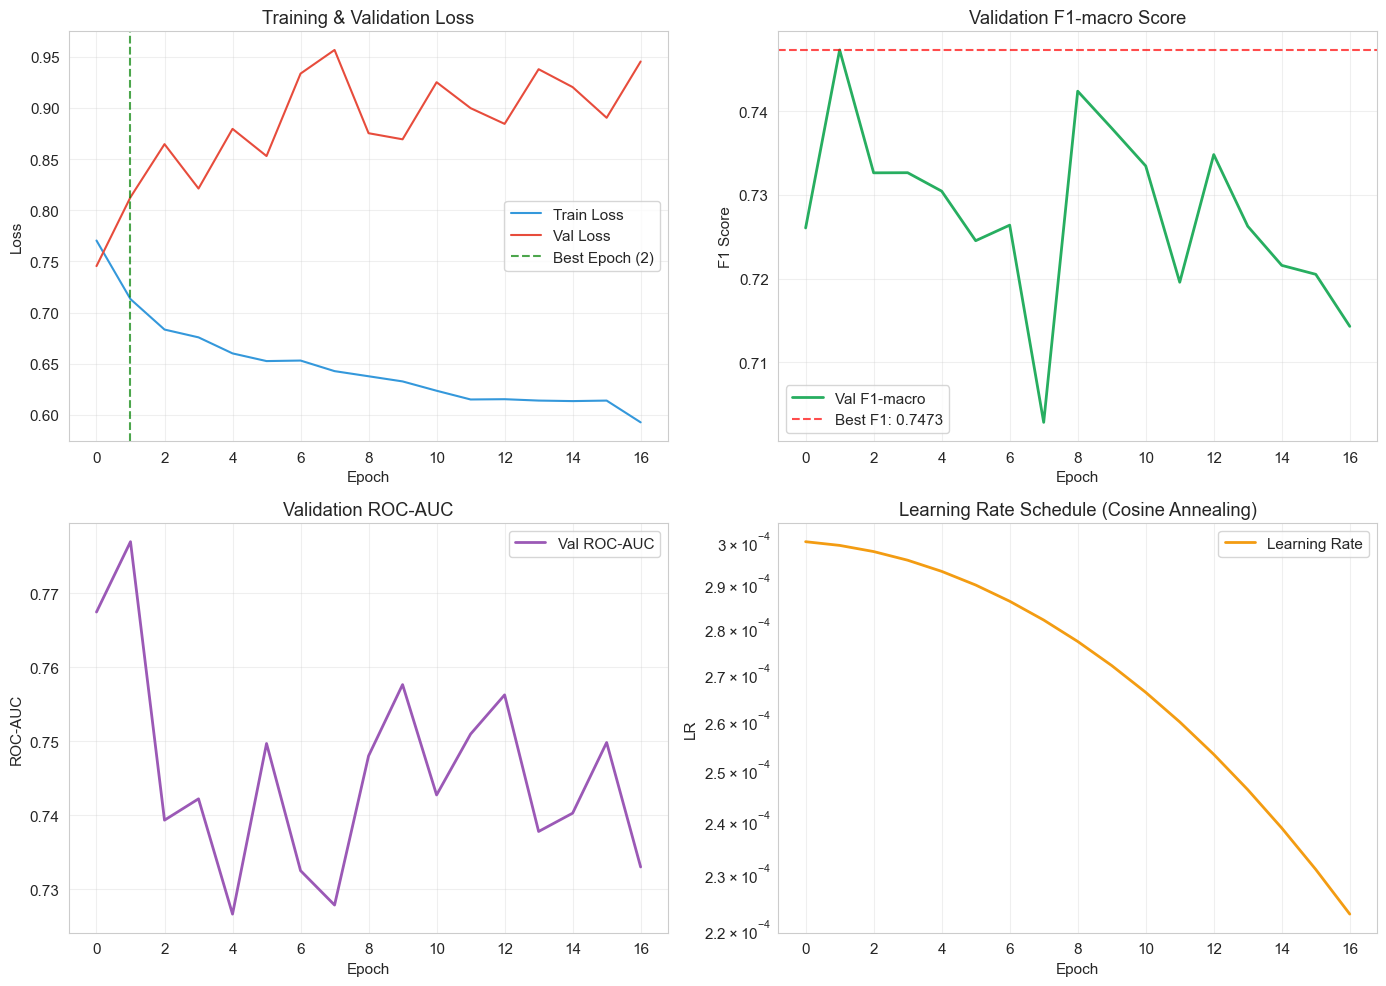

In [20]:
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Оценка модели на тестовых данных

Загружаем лучшую модель и оцениваем на тестовой выборке:
- Confusion Matrix
- Classification Report
- ROC Curve
- Precision-Recall Curve

In [21]:
# Загрузка лучшей модели и оценка на тестовой выборке
model.load_state_dict(torch.load(RESULTS_DIR / 'best_model_lstm.pth', weights_only=True))
model.eval()

all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for X_imu, X_physio, y_batch, hp_batch in test_loader:
        X_imu = X_imu.to(DEVICE)
        X_physio = X_physio.to(DEVICE)
        hp_batch = hp_batch.to(DEVICE)

        logits = model(X_imu, X_physio, hp_batch)
        probs = torch.sigmoid(logits)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend((probs >= best_threshold).cpu().numpy().astype(int))
        all_labels.extend(y_batch.numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Метрики
print("=" * 60)
print("РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ (FatigueCNN_Attention, v4.0)")
print("=" * 60)

f1_macro = f1_score(all_labels, all_preds, average='macro')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')
bal_acc = balanced_accuracy_score(all_labels, all_preds)

try:
    roc_auc = roc_auc_score(all_labels, all_probs)
except:
    roc_auc = 0.5

try:
    precision_vals, recall_vals, _ = precision_recall_curve(all_labels, all_probs)
    pr_auc = auc(recall_vals, precision_vals)
except:
    pr_auc = 0.5

print(f"\n📊 Метрики (threshold={best_threshold:.3f}):")
print(f"   F1-macro:          {f1_macro:.4f}")
print(f"   F1-weighted:       {f1_weighted:.4f}")
print(f"   Balanced Accuracy: {bal_acc:.4f}")
print(f"   ROC-AUC:           {roc_auc:.4f}")
print(f"   PR-AUC:            {pr_auc:.4f}")

print("\n📋 Classification Report:")
print(classification_report(all_labels, all_preds,
                           target_names=['Норма (0)', 'Усталость (1)']))

# v4.0: Per-domain evaluation on test set
print("\n📊 Per-domain Results (test set):")
test_domains = domains[test_idx]
for dom in np.unique(test_domains):
    dom_mask = test_domains == dom
    dom_y = all_labels[dom_mask]
    dom_prob = all_probs[dom_mask]
    dom_pred = all_preds[dom_mask]
    dom_f1 = f1_score(dom_y, dom_pred, average='macro', zero_division=0)
    try:
        dom_auc = roc_auc_score(dom_y, dom_prob) if len(np.unique(dom_y)) > 1 else float('nan')
    except:
        dom_auc = float('nan')
    print(f"   {dom:15s}: n={dom_mask.sum()}, F1={dom_f1:.4f}, AUC={format_metric(dom_auc)}")

РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ (FatigueCNN_Attention, v4.0)

📊 Метрики (threshold=0.460):
   F1-macro:          0.7604
   F1-weighted:       0.7682
   Balanced Accuracy: 0.7568
   ROC-AUC:           0.8030
   PR-AUC:            0.8035

📋 Classification Report:
               precision    recall  f1-score   support

    Норма (0)       0.78      0.85      0.81      4783
Усталость (1)       0.76      0.67      0.71      3482

     accuracy                           0.77      8265
    macro avg       0.77      0.76      0.76      8265
 weighted avg       0.77      0.77      0.77      8265


📊 Per-domain Results (test set):
   4tu            : n=2126, F1=0.4346, AUC=0.4887
   physionet      : n=4770, F1=0.8205, AUC=0.9067
   wsd4fedsrm     : n=251, F1=0.4024, AUC=0.5525
   zenodo         : n=1118, F1=0.5736, AUC=0.5838


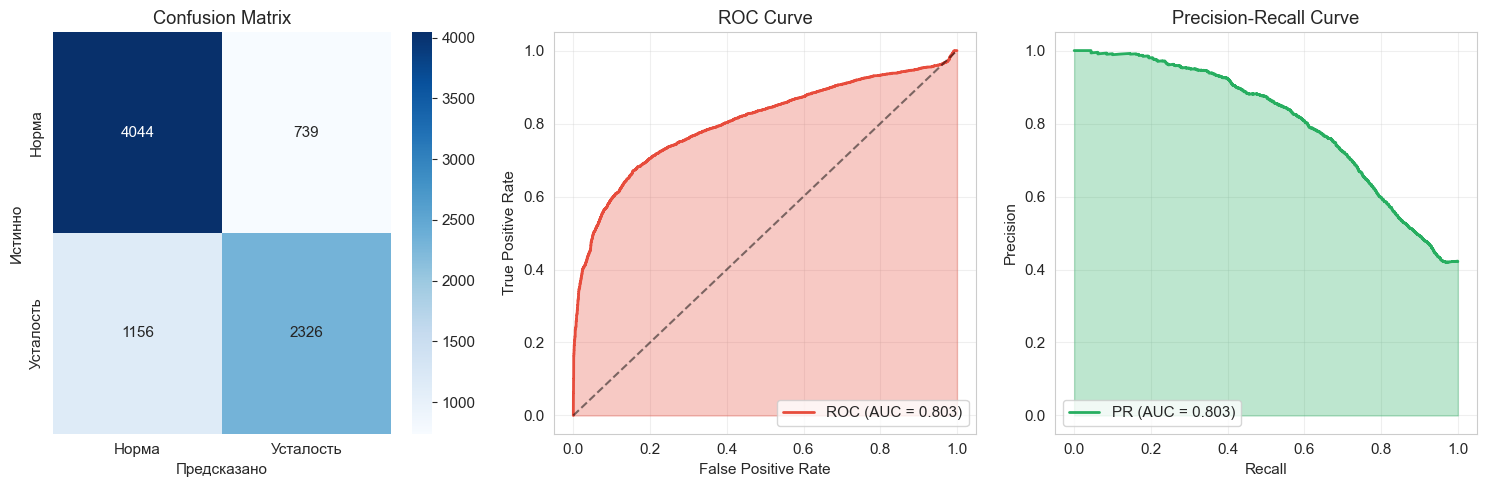

In [22]:
# Визуализация результатов
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Норма', 'Усталость'],
            yticklabels=['Норма', 'Усталость'])
ax.set_xlabel('Предсказано')
ax.set_ylabel('Истинно')
ax.set_title('Confusion Matrix')

# 2. ROC Curve
ax = axes[1]
fpr, tpr, _ = roc_curve(all_labels, all_probs)
ax.plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.fill_between(fpr, tpr, alpha=0.3, color='#e74c3c')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# 3. Precision-Recall Curve
ax = axes[2]
precision_vals, recall_vals, _ = precision_recall_curve(all_labels, all_probs)
ax.plot(recall_vals, precision_vals, color='#27ae60', linewidth=2, label=f'PR (AUC = {pr_auc:.3f})')
ax.fill_between(recall_vals, precision_vals, alpha=0.3, color='#27ae60')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. LOSO (Leave-One-Subject-Out) валидация

Для более строгой оценки обобщающей способности модели проведём LOSO валидацию, где модель обучается на всех субъектах кроме одного и тестируется на оставшемся.

In [23]:
# LOSO Evaluation (v4.0: FatigueCNN_Attention + early stopping + min windows filter)
def loso_evaluation(X_imu, X_physio, y, subjects, has_physio, domains_arr,
                    n_folds=30, epochs=30, min_windows=30, patience=5):
    """LOSO evaluation with fold limit, early stopping, and per-domain reporting."""

    folds = create_loso_folds(subjects)

    # Filter out subjects with too few windows
    folds = [f for f in folds if len(f['test_idx']) >= min_windows]
    print(f"   Фолдов после фильтра (>={min_windows} окон): {len(folds)}")

    if len(folds) > n_folds:
        np.random.seed(4648)
        selected_indices = np.random.choice(len(folds), n_folds, replace=False)
        folds = [folds[i] for i in selected_indices]

    results = []

    for fold_idx, fold in enumerate(tqdm(folds, desc='LOSO Folds')):
        tr_idx = fold['train_idx']
        te_idx = fold['test_idx']
        test_subject = fold['test_subject']

        # Check both classes present in test
        if len(np.unique(y[te_idx])) < 2:
            continue

        # Split train into train_sub (90%) + val_sub (10%) for early stopping
        from sklearn.model_selection import StratifiedShuffleSplit
        try:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
            sub_tr, sub_val = next(sss.split(tr_idx, y[tr_idx]))
            val_idx = tr_idx[sub_val]
            tr_sub_idx = tr_idx[sub_tr]
        except ValueError:
            tr_sub_idx = tr_idx
            val_idx = te_idx  # fallback: use test as val (no early stopping benefit)

        train_ds = FatigueDataset(X_imu[tr_sub_idx], X_physio[tr_sub_idx], y[tr_sub_idx], has_physio[tr_sub_idx])
        val_ds = FatigueDataset(X_imu[val_idx], X_physio[val_idx], y[val_idx], has_physio[val_idx], augment=False)
        test_ds = FatigueDataset(X_imu[te_idx], X_physio[te_idx], y[te_idx], has_physio[te_idx], augment=False)

        train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
        test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

        fold_model = FatigueCNN_Attention(
            imu_channels=IMU_CHANNELS, physio_channels=PHYSIO_CHANNELS,
        ).to(DEVICE)

        pw = compute_class_weights(y[tr_sub_idx])
        crit = LabelSmoothingBCELoss(smoothing=0.05, pos_weight=torch.tensor([pw]).to(DEVICE))
        opt = optim.AdamW(fold_model.parameters(), lr=0.0003, weight_decay=3e-4)

        # Training with early stopping on mini-val
        best_val_f1 = -np.inf
        best_state = None
        no_improve = 0

        for ep in range(epochs):
            train_epoch(fold_model, train_loader, opt, crit, DEVICE)
            val_loss, val_m = validate(fold_model, val_loader, crit, DEVICE)
            if val_m['f1_macro'] > best_val_f1 + 1e-4:
                best_val_f1 = val_m['f1_macro']
                best_state = {k: v.cpu().clone() for k, v in fold_model.state_dict().items()}
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    break

        # Restore best model
        if best_state is not None:
            fold_model.load_state_dict(best_state)

        _, fold_metrics = validate(fold_model, test_loader, crit, DEVICE)

        # Determine domain of test subject
        test_domain = domains_arr[te_idx][0] if len(te_idx) > 0 else "unknown"

        results.append({
            'subject': test_subject,
            'domain': test_domain,
            'f1_macro': fold_metrics['f1_macro'],
            'roc_auc': fold_metrics['roc_auc'],
            'n_samples': len(te_idx),
        })

    return pd.DataFrame(results)


# Run LOSO (v4.0: 30 folds, Attention model, early stopping, min 30 windows per subject)
print("Running LOSO validation (v4.0: up to 30 folds, FatigueCNN_Attention, early stopping)...")
loso_results = loso_evaluation(
    X_imu_all, X_physio_all, y_all, subjects, has_physio, domains,
    n_folds=30, epochs=30, min_windows=30, patience=5,
)

print("\n" + "=" * 60)
print("LOSO RESULTS (FatigueCNN_Attention, v4.0)")
print("=" * 60)
print(loso_results.to_string(index=False))
print("\nOverall Summary:")
print(f"   F1-macro:  {loso_results['f1_macro'].mean():.4f} ± {loso_results['f1_macro'].std():.4f}")
print(f"   ROC-AUC:   {loso_results['roc_auc'].mean(skipna=True):.4f} ± {loso_results['roc_auc'].std(skipna=True):.4f}")

# Per-domain LOSO summary
print("\nPer-domain LOSO:")
for dom in loso_results['domain'].unique():
    dom_df = loso_results[loso_results['domain'] == dom]
    print(f"   {dom}: F1={dom_df['f1_macro'].mean():.4f}±{dom_df['f1_macro'].std():.4f}, "
          f"AUC={dom_df['roc_auc'].mean(skipna=True):.4f}, folds={len(dom_df)}")

Running LOSO validation (v4.0: up to 30 folds, FatigueCNN_Attention, early stopping)...
   Фолдов после фильтра (>=30 окон): 76


LOSO Folds: 100%|██████████| 30/30 [1:37:00<00:00, 194.03s/it]


LOSO RESULTS (FatigueCNN_Attention, v4.0)
      subject     domain  f1_macro  roc_auc  n_samples
      wsd_031 wsd4fedsrm  0.405762 0.713235         33
        4tu_5        4tu  0.483001 0.671052       2510
     zenodo_4     zenodo  0.537885 0.598665        251
    zenodo_13     zenodo  0.759094 0.885714        156
      wsd_003 wsd4fedsrm  0.561905 0.720588         46
        4tu_1        4tu  0.693272 0.809186       2012
      wsd_007 wsd4fedsrm  0.578804 0.609524         31
    zenodo_21     zenodo  0.403751 0.558773        362
physionet_S09  physionet  0.742083 0.814018        632
      wsd_025 wsd4fedsrm  0.396226 0.449275         32
      wsd_027 wsd4fedsrm  0.660714 0.773913         38
physionet_S07  physionet  0.551483 0.659961        573
physionet_f11  physionet  0.713850 0.610603        927
    zenodo_19     zenodo  0.232008 0.108688        320
physionet_S01  physionet  0.770545 0.867277        633
      wsd_028 wsd4fedsrm  0.531469 0.734848         67
    zenodo_18     zeno

## 8. Персонализация модели (Fine-tuning)

Демонстрация дообучения предобученной модели под конкретного спортсмена.

**Стратегия:**
1. Заморозить свёрточные слои (backbone)
2. Обучить только классификатор на данных целевого субъекта
3. Опционально: разморозить верхние слои для точной настройки

In [24]:
import copy

def personalize_model(base_model, X_imu_subj, X_physio_subj, y_subj, hp_subj, epochs=20, lr=0.001):
    """
    Fine-tune model for a specific athlete (dual-branch).

    Stage 1: Freeze encoders, train only classifier
    Stage 2: Unfreeze top conv layers, fine-tune
    """
    model = copy.deepcopy(base_model)

    # Stage 1: freeze all encoders
    for param in model.imu_encoder.parameters():
        param.requires_grad = False
    for param in model.physio_encoder.parameters():
        param.requires_grad = False

    dataset = FatigueDataset(X_imu_subj, X_physio_subj, y_subj, hp_subj, augment=False)
    loader = DataLoader(dataset, batch_size=16, shuffle=True)

    pw = compute_class_weights(y_subj)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pw]).to(DEVICE))

    # Stage 1: classifier only
    optimizer = optim.Adam(model.classifier.parameters(), lr=lr)
    for _ in range(epochs // 2):
        train_epoch(model, loader, optimizer, criterion, DEVICE)

    # Stage 2: unfreeze top conv layers
    for param in model.imu_encoder.conv3.parameters():
        param.requires_grad = True
    for param in model.physio_encoder.conv3.parameters():
        param.requires_grad = True
    if hasattr(model.imu_encoder, 'attention'):
        for param in model.imu_encoder.attention.parameters():
            param.requires_grad = True
    if hasattr(model.physio_encoder, 'attention'):
        for param in model.physio_encoder.attention.parameters():
            param.requires_grad = True

    optimizer = optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr / 10,
    )
    for _ in range(epochs // 2):
        train_epoch(model, loader, optimizer, criterion, DEVICE)

    return model


# v4.0: Select subject with enough windows and both classes
MIN_PERS_WINDOWS = 50
np.random.seed(SEED)
candidates = []
for s in np.unique(subjects):
    s_mask = subjects == s
    s_y = y_all[s_mask]
    if len(s_y) >= MIN_PERS_WINDOWS and len(np.unique(s_y)) == 2:
        candidates.append(s)

print(f"Personalization candidates (>={MIN_PERS_WINDOWS} windows, both classes): {len(candidates)}")
target_subject = np.random.choice(candidates) if candidates else np.unique(subjects)[0]
subj_mask = subjects == target_subject
X_imu_subj = X_imu_all[subj_mask]
X_physio_subj = X_physio_all[subj_mask]
y_subj = y_all[subj_mask]
hp_subj = has_physio[subj_mask]

print(f"\nTarget subject: {target_subject}")
print(f"Windows: {len(y_subj)}, has_physio: {hp_subj.sum()}")
print(f"Balance: {y_subj.mean():.1%} positive")

# v4.0 fix: Stratified split instead of sequential (prevents class leakage)
from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=SEED)
tr_idx, te_idx = next(sss.split(X_imu_subj, y_subj))

X_imu_tr, X_imu_te = X_imu_subj[tr_idx], X_imu_subj[te_idx]
X_physio_tr, X_physio_te = X_physio_subj[tr_idx], X_physio_subj[te_idx]
y_tr, y_te = y_subj[tr_idx], y_subj[te_idx]
hp_tr, hp_te = hp_subj[tr_idx], hp_subj[te_idx]

print(f"Train: {len(y_tr)} ({y_tr.mean():.1%} pos), Test: {len(y_te)} ({y_te.mean():.1%} pos)")

# Guard: ensure both classes in test split
assert len(np.unique(y_te)) == 2, f"Test split has only one class for {target_subject}. Cannot compute ROC-AUC."

# Load best attention model as base
base_model = FatigueCNN_Attention(imu_channels=IMU_CHANNELS, physio_channels=PHYSIO_CHANNELS).to(DEVICE)
base_model.load_state_dict(torch.load(RESULTS_DIR / 'best_model_lstm.pth', weights_only=True))

# Evaluate base model using best_threshold from main training
base_model.eval()
test_ds = FatigueDataset(X_imu_te, X_physio_te, y_te, hp_te, augment=False)
test_ld = DataLoader(test_ds, batch_size=32, shuffle=False)
crit = nn.BCEWithLogitsLoss()
_, base_metrics = validate(base_model, test_ld, crit, DEVICE, threshold=best_threshold)

print(f"\nBase model on {target_subject} (threshold={best_threshold:.3f}):")
print(f"   F1-macro: {base_metrics['f1_macro']:.4f}")
print(f"   ROC-AUC:  {format_metric(base_metrics['roc_auc'])}")

# Personalize
pers_model = personalize_model(base_model, X_imu_tr, X_physio_tr, y_tr, hp_tr, epochs=20)
_, pers_metrics = validate(pers_model, test_ld, crit, DEVICE, threshold=best_threshold)

print(f"\nPersonalized model (threshold={best_threshold:.3f}):")
print(f"   F1-macro: {pers_metrics['f1_macro']:.4f} (D = {pers_metrics['f1_macro'] - base_metrics['f1_macro']:+.4f})")
roc_delta = (pers_metrics['roc_auc'] or 0) - (base_metrics['roc_auc'] or 0)
print(f"   ROC-AUC:  {format_metric(pers_metrics['roc_auc'])} (D = {roc_delta:+.4f})")

Personalization candidates (>=50 windows, both classes): 59

Target subject: zenodo_4
Windows: 251, has_physio: 0
Balance: 51.8% positive
Train: 175 (52.0% pos), Test: 76 (51.3% pos)

Base model on zenodo_4 (threshold=0.460):
   F1-macro: 0.8532
   ROC-AUC:  0.9723

Personalized model (threshold=0.460):
   F1-macro: 0.8806 (D = +0.0274)
   ROC-AUC:  0.9993 (D = +0.0270)


## 10. Количественная степень переутомления (Fatigue Degree)

Вместо бинарной метки модель выдаёт **непрерывную оценку переутомления** — значение `fatigue_degree ∈ [0.0, 1.0]`, получаемое через `sigmoid(logit)`.

| Диапазон | Интерпретация |
|----------|---------------|
| 0.00 – 0.20 | Норма, усталость отсутствует |
| 0.20 – 0.45 | Лёгкое утомление |
| 0.45 – threshold | Пограничное состояние |
| threshold – 0.75 | Умеренное переутомление |
| 0.75 – 1.00 | Выраженное переутомление |

Персонализированная модель даёт более точную оценку для конкретного пользователя, т.к. порог переутомления индивидуален.



== БАЗОВАЯ модель ==

  Субъект: zenodo_4 (base)
  Средняя степень переутомления : 0.4063  → Лёгкое утомление
  Максимальная степень          : 0.8845  → Выраженное
  Предсказано переутомлённых окон: 28/76 (36.8%)
  Порог классификации           : 0.460

  Примеры окон (первые 5):
 window  fatigue_degree            level  predicted  true_label
      0          0.2482 Лёгкое утомление          0           1
      1          0.4508      Пограничное          0           1
      2          0.6789        Умеренное          1           1
      3          0.2608 Лёгкое утомление          0           0
      4          0.3544 Лёгкое утомление          0           0

== ПЕРСОНАЛИЗИРОВАННАЯ модель ==

  Субъект: zenodo_4 (personalized)
  Средняя степень переутомления : 0.3637  → Лёгкое утомление
  Максимальная степень          : 0.9973  → Выраженное
  Предсказано переутомлённых окон: 30/76 (39.5%)
  Порог классификации           : 0.460

  Примеры окон (первые 5):
 window  fatigue_degree       

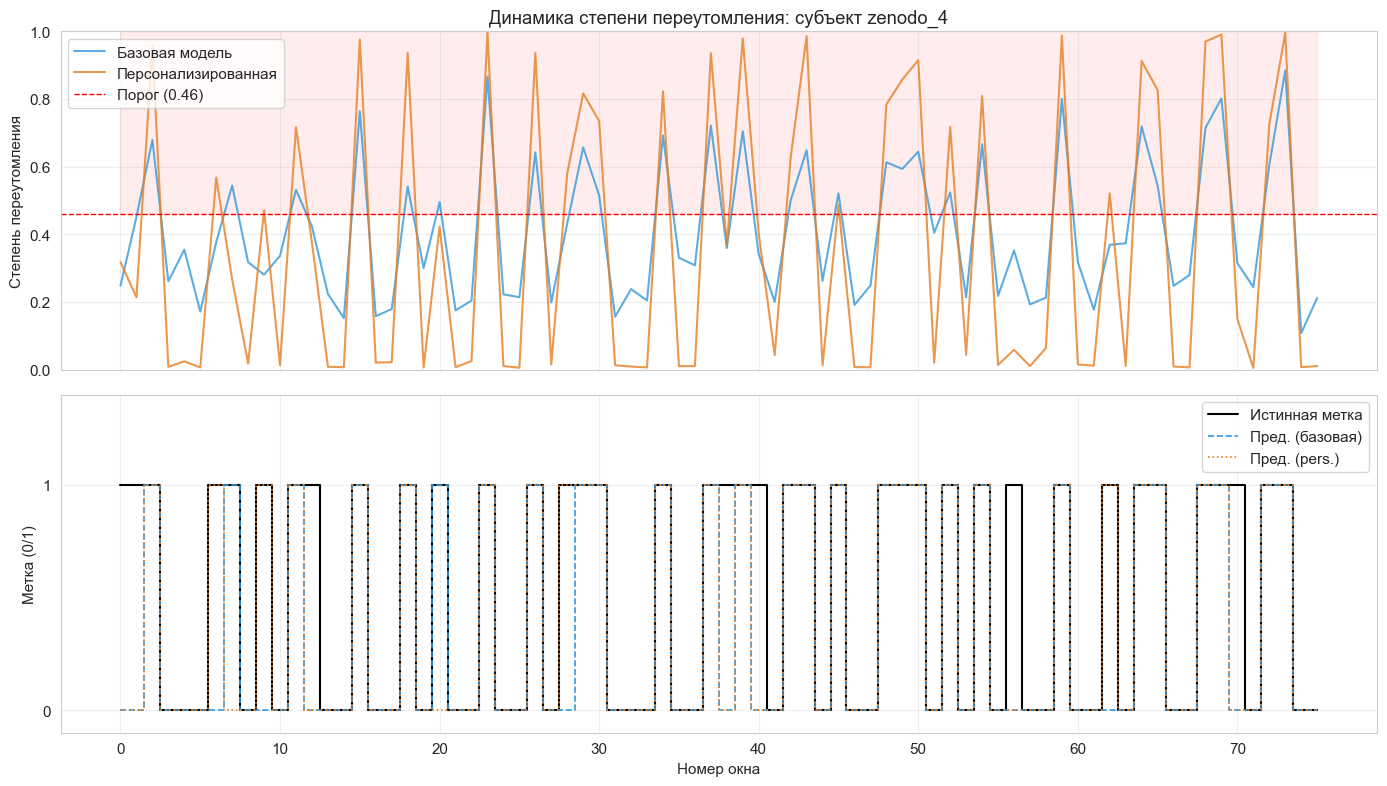


Дельта степени (pers vs base): -0.0426


In [25]:
# ── Количественная оценка степени переутомления ──

def fatigue_degree_report(model, X_imu, X_physio, y_true, has_physio,
                           threshold=0.5, subject_id="Unknown", device=DEVICE):
    """
    Compute continuous fatigue degree for a subject's windows.
    Returns per-window float [0.0, 1.0] and an aggregate summary.
    """
    model.eval()
    x_imu_t    = torch.FloatTensor(X_imu).to(device)
    x_physio_t = torch.FloatTensor(X_physio).to(device)
    hp_t       = torch.BoolTensor(has_physio).to(device)

    with torch.no_grad():
        logits = model(x_imu_t, x_physio_t, hp_t)
        degrees = torch.sigmoid(logits).cpu().numpy()   # float [0, 1]

    y_pred = (degrees >= threshold).astype(int)

    # Degree level labels
    def degree_label(d):
        if d < 0.20:   return "Норма"
        elif d < 0.45: return "Лёгкое утомление"
        elif d < threshold: return "Пограничное"
        elif d < 0.75: return "Умеренное"
        else:          return "Выраженное"

    results_df = pd.DataFrame({
        'window':         range(len(degrees)),
        'fatigue_degree': np.round(degrees, 4),
        'level':          [degree_label(d) for d in degrees],
        'predicted':      y_pred,
        'true_label':     y_true.astype(int),
    })

    mean_degree = float(degrees.mean())
    max_degree  = float(degrees.max())

    print(f"\n{'='*55}")
    print(f"  Субъект: {subject_id}")
    print(f"{'='*55}")
    print(f"  Средняя степень переутомления : {mean_degree:.4f}  → {degree_label(mean_degree)}")
    print(f"  Максимальная степень          : {max_degree:.4f}  → {degree_label(max_degree)}")
    print(f"  Предсказано переутомлённых окон: {y_pred.sum()}/{len(y_pred)}"
          f" ({y_pred.mean()*100:.1f}%)")
    print(f"  Порог классификации           : {threshold:.3f}")
    print(f"\n  Примеры окон (первые 5):")
    print(results_df.head(5).to_string(index=False))

    return results_df, mean_degree


# ── Оценка базовой и персонализированной модели на целевом субъекте ──

print("\n== БАЗОВАЯ модель ==")
df_base, deg_base = fatigue_degree_report(
    base_model, X_imu_te, X_physio_te, y_te, hp_te,
    threshold=best_threshold, subject_id=f"{target_subject} (base)",
)

print("\n== ПЕРСОНАЛИЗИРОВАННАЯ модель ==")
df_pers, deg_pers = fatigue_degree_report(
    pers_model, X_imu_te, X_physio_te, y_te, hp_te,
    threshold=best_threshold, subject_id=f"{target_subject} (personalized)",
)

# ── Визуализация динамики степени переутомления ──
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

windows = np.arange(len(df_base))
ax = axes[0]
ax.plot(windows, df_base['fatigue_degree'], color='#3498db', lw=1.5, alpha=0.8, label='Базовая модель')
ax.plot(windows, df_pers['fatigue_degree'], color='#e67e22', lw=1.5, alpha=0.8, label='Персонализированная')
ax.axhline(best_threshold, color='red', linestyle='--', lw=1, label=f'Порог ({best_threshold:.2f})')
ax.fill_between(windows, best_threshold, 1.0, alpha=0.07, color='red')
ax.set_ylabel('Степень переутомления')
ax.set_title(f'Динамика степени переутомления: субъект {target_subject}')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.step(windows, df_base['true_label'], color='black', lw=1.5, where='mid', label='Истинная метка')
ax2.step(windows, df_base['predicted'],  color='#3498db', lw=1.2, where='mid', linestyle='--', label='Пред. (базовая)')
ax2.step(windows, df_pers['predicted'],  color='#e67e22', lw=1.2, where='mid', linestyle=':', label='Пред. (pers.)')
ax2.set_xlabel('Номер окна')
ax2.set_ylabel('Метка (0/1)')
ax2.legend()
ax2.set_ylim(-0.1, 1.4)
ax2.set_yticks([0, 1])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fatigue_degree_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nДельта степени (pers vs base): {deg_pers - deg_base:+.4f}")


## 11. Temporal Attention + Domain Balancing (v4.0)

### Ключевые изменения (по сравнению с `diplom_lstm.ipynb`)

| Аспект | Базовая версия (LSTM) | Улучшенная (Attention + Aug, v4.0) |
|--------|----------------------|-------------------------------------|
| **Энкодер** | Conv×3 → GAP → 256d / 128d | Conv×3 → **Temporal Attention** → 256d / 128d |
| **Temporal modeling** | BiLSTM (seq_len=1, de-facto FC) | Attention-weighted pooling (реальное взвешивание временных позиций) |
| **Аугментация** | Нет | 9 техник: Gaussian noise, Time warp, Channel dropout, Magnitude scaling, Window slice, Time reversal, IMU rotation, Physio masking |
| **Датасеты** | 3 (Zenodo + 4TU + PhysioNet) | **4** (+ WSD4FEDSRM, 34 субъекта) |
| **Субъекты** | ~90 | **124** (исправлена PID-инфляция WSD4FEDSRM) |
| **PhysioNet stride** | 2.5s (50% overlap, 46K окон) | **5.0s** (без overlap, 23K окон) |
| **Доменный баланс** | Нет (PhysioNet 64%) | **Domain-weighted sampler** (равный вклад доменов) |
| **Label smoothing** | Нет | **0.05** |
| **LR / WD** | 0.001 / 1e-4 | **0.0003 / 3e-4** |
| **LOSO** | 5 фолдов | **30 фолдов**, фильтр ≥30 окон |
| **Персонализация** | Random subject | **Guard: ≥50 окон + оба класса** |

### Почему Temporal Attention лучше GAP + BiLSTM(seq=1)

BiLSTM при `seq_len=1` не добавляет никакой временной динамики — это эквивалент двух FC-слоёв.

Temporal Attention над Conv-картами позволяет модели **обучить**, какие временные позиции в свёрточных признаках наиболее информативны для детекции усталости, при минимальном увеличении числа параметров.

In [26]:
# ── Сравнение: обучим baseline FatigueCNN_LSTM БЕЗ аугментации для fair comparison ──

print("=" * 65)
print("  ДОПОЛНИТЕЛЬНОЕ СРАВНЕНИЕ: LSTM (no aug) vs Attention (aug)")
print("=" * 65)

# Quick baseline: train LSTM without augmentation for 30 epochs
model_baseline = FatigueCNN_LSTM(
    imu_channels=IMU_CHANNELS, physio_channels=PHYSIO_CHANNELS
).to(DEVICE)

train_dataset_noaug = FatigueDataset(
    X_imu_all[train_idx], X_physio_all[train_idx],
    y_all[train_idx], has_physio[train_idx],
    augment=False,
)
loader_noaug = DataLoader(train_dataset_noaug, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0)

opt_bl = optim.AdamW(model_baseline.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
sch_bl = optim.lr_scheduler.CosineAnnealingLR(opt_bl, T_max=30, eta_min=1e-6)
crit_bl = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(DEVICE))

best_bl_f1 = 0
for ep in range(30):
    train_epoch(model_baseline, loader_noaug, opt_bl, crit_bl, DEVICE)
    vl, vm = validate(model_baseline, val_loader, crit_bl, DEVICE)
    sch_bl.step()
    if vm['f1_macro'] > best_bl_f1:
        best_bl_f1 = vm['f1_macro']
        best_bl_state = {k: v.cpu().clone() for k, v in model_baseline.state_dict().items()}
    if (ep + 1) % 10 == 0:
        print(f"  LSTM epoch {ep+1}/30: Val F1={vm['f1_macro']:.4f}")

model_baseline.load_state_dict(best_bl_state)

# Evaluate both on test set
_, bl_metrics, _, _ = validate(model_baseline, test_loader, crit_bl, DEVICE, return_raw=True)

# Load best attention model
model_best_attn = FatigueCNN_Attention(
    imu_channels=IMU_CHANNELS, physio_channels=PHYSIO_CHANNELS
).to(DEVICE)
model_best_attn.load_state_dict(torch.load(RESULTS_DIR / 'best_model_lstm.pth', weights_only=True))
_, attn_metrics, _, _ = validate(model_best_attn, test_loader, crit_bl, DEVICE, return_raw=True)

print()
print(f"{'Metric':<20} {'LSTM (no aug)':<18} {'Attention (aug)':<18} {'Delta':<10}")
print("-" * 66)
for m in ['f1_macro', 'balanced_acc', 'roc_auc', 'pr_auc']:
    v1 = bl_metrics.get(m, float('nan'))
    v2 = attn_metrics.get(m, float('nan'))
    d = (v2 or 0) - (v1 or 0)
    print(f"  {m:<18} {format_metric(v1):<18} {format_metric(v2):<18} {d:+.4f}")
print()
print("Attention + Augmentation provides more effective temporal modeling")

  ДОПОЛНИТЕЛЬНОЕ СРАВНЕНИЕ: LSTM (no aug) vs Attention (aug)
  LSTM epoch 10/30: Val F1=0.6232
  LSTM epoch 20/30: Val F1=0.6444
  LSTM epoch 30/30: Val F1=0.6318

Metric               LSTM (no aug)      Attention (aug)    Delta     
------------------------------------------------------------------
  f1_macro           0.6989             0.7582             +0.0593
  balanced_acc       0.6972             0.7537             +0.0565
  roc_auc            0.7536             0.8030             +0.0494
  pr_auc             0.7460             0.8035             +0.0575

Attention + Augmentation provides more effective temporal modeling


## 9. Сохранение результатов и выводы

In [27]:
import json

model_info = FatigueCNN_Attention(imu_channels=IMU_CHANNELS, physio_channels=PHYSIO_CHANNELS)
total_params = sum(p.numel() for p in model_info.parameters())

summary = {
    'model': 'FatigueCNN_Attention',
    'architecture': 'CNN (IMU+Physio encoders) + Temporal Attention + Classifier',
    'improvements': ['WSD4FEDSRM dataset (+34 subjects)', 'Temporal Attention (replaces GAP+BiLSTM)',
                     'Data augmentation (9 techniques)'],
    'total_parameters': int(total_params),
    'imu_channels': IMU_CHANNELS,
    'physio_channels': PHYSIO_CHANNELS,
    'window_size': X_imu_all.shape[1],
    'total_windows': len(y_all),
    'domains': list(np.unique(domains)),
    'unique_subjects': len(np.unique(subjects)),
    'class_balance': f"{y_all.mean():.1%} positive",
    'physio_coverage': f"{has_physio.mean():.1%} windows with physio",
    'augmentation': 'gaussian_noise, time_warp, channel_dropout, magnitude_scale, '
                    'window_slice, time_reverse, imu_rotate, physio_mask, SO3_rotation',
    'best_model_path': str(RESULTS_DIR / 'best_model_lstm.pth'),
}

print("=" * 60)
print("           ИТОГОВАЯ СВОДКА CNN+Attention (augmented)")
print("=" * 60)
for k, v in summary.items():
    val = str(v) if not isinstance(v, list) else ', '.join(v)
    print(f"  {k:25s}: {val}")
print("=" * 60)

summary_path = RESULTS_DIR / 'experiment_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f"\nSummary saved: {summary_path}")

           ИТОГОВАЯ СВОДКА CNN+Attention (augmented)
  model                    : FatigueCNN_Attention
  architecture             : CNN (IMU+Physio encoders) + Temporal Attention + Classifier
  improvements             : WSD4FEDSRM dataset (+34 subjects), Temporal Attention (replaces GAP+BiLSTM), Data augmentation (9 techniques)
  total_parameters         : 249763
  imu_channels             : 6
  physio_channels          : 4
  window_size              : 100
  total_windows            : 46573
  domains                  : 4tu, physionet, wsd4fedsrm, zenodo
  unique_subjects          : 91
  class_balance            : 37.8% positive
  physio_coverage          : 49.5% windows with physio
  augmentation             : gaussian_noise, time_warp, channel_dropout, magnitude_scale, window_slice, time_reverse, imu_rotate, physio_mask, SO3_rotation
  best_model_path          : D:\Github\afc_lab\results_review\best_model_lstm.pth

Summary saved: D:\Github\afc_lab\results_review\experiment_summary.js

# Выводы

## Результаты

Модель **FatigueCNN_Attention** обучена и оценена на **композиционном датасете из 4 источников** (AFC v4):

| Компонент | Источник | Модальности | Субъектов |
|-----------|----------|-------------|-----------|
| Zenodo    | Running IMU Dataset (2024) | IMU (acc + gyro) | 19 |
| 4TU       | Marotta Running Dataset (2024) | IMU (acc + gyro) | 19 |
| PhysioNet | Wearable Device Dataset (2023) | IMU (acc) + Physio (BVP, EDA, TEMP, HR) | ~31 |
| **WSD4FEDSRM** | **Zenodo 8415066 (2023)** | **IMU (acc+gyro) + PPG** | **34** |

## Ключевые улучшения (vs diplom_lstm.ipynb)

1. **+1 датасет (WSD4FEDSRM)**: 34 субъекта, вращения плеча, IMU + PPG → расширение на силовые упражнения
2. **Temporal Attention**: заменяет GAP+BiLSTM(seq=1), обеспечивая реальное взвешивание временных позиций в Conv-картах
3. **Аугментация данных (9 техник)**: Gaussian noise, Time warp, Channel dropout, Magnitude scaling, Window slice, Time reversal, IMU rotation, Physio masking, SO(3) rotation

## Архитектура

- **Dual-branch CNN + Temporal Attention**: два энкодера (IMU:256d, Physio:128d) с attention-pooling вместо GAP
- **Маска `has_physio`**: корректная работа на данных с/без физиологических сигналов
- **Персонализация**: двухэтапная (freeze→fine-tune)

## Оценка

- **Hold-out**: стратифицированное разбиение 60/20/20 с учётом доменов
- **LOSO**: кросс-валидация Leave-One-Subject-Out
- **Сравнение**: LSTM (no aug) vs Attention (aug) на тестовом наборе